# 03 — Modeling (20% Dataset)

This notebook trains all models on the **20% stratified dataset** created in `02_Preprocessing_20percent.ipynb`.

Models trained:
- Logistic Regression  
- Logistic Regression (Balanced)  
- Linear SVM  
- RBF SVM (Nystroem Approx)  
- Fast RBF SVM (RBFSampler)  
- Sigmoid SVM  
- FAISS Classifier  
- Neural Network (Baseline)  
- Neural Network (LBFGS Stable)  
- Neural Network (SMOTE + Threshold Tuning)

All results are recorded in `results_20`.

### Imports + Load 20% Processed Dataset

In [1]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, f1_score,
    recall_score, precision_score
)

# Load processed 20% dataset
df = pd.read_csv("../data/processed/processed_20/processed_train_20.csv")

df.head()

,ApplicantYears,AnnualEarnings,RequestedSum,TrustMetric,WorkDuration,ActiveAccounts,OfferRate,RepayPeriod,DebtFactor,OwnsProperty,...,WorkCategory_Part-time,WorkCategory_Self-employed,WorkCategory_Unemployed,RelationshipStatus_Married,RelationshipStatus_Single,FundUseCase_Business,FundUseCase_Education,FundUseCase_Home,FundUseCase_Other,RiskFlag
0,23,27572,229992,309,106,4,6.04,24,0.34,1,...,False,True,False,False,False,False,False,True,False,0
1,45,113188,74419,709,18,4,17.17,48,0.24,0,...,True,False,False,True,False,False,False,False,True,0
2,28,102613,8635,706,47,4,6.75,60,0.73,1,...,False,True,False,True,False,False,True,False,False,0
3,47,48486,245755,667,26,2,22.04,48,0.37,0,...,False,False,False,False,False,False,False,False,False,0
4,18,88172,32171,392,8,2,21.83,48,0.38,0,...,False,True,False,True,False,False,False,False,True,0


### Train-test split + Scale numerical features

In [2]:
# Separate target
X = df.drop("RiskFlag", axis=1)
y = df["RiskFlag"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Numerical columns
numerical_cols = [
    "ApplicantYears","AnnualEarnings","RequestedSum","TrustMetric",
    "WorkDuration","ActiveAccounts","OfferRate","RepayPeriod","DebtFactor"
]

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

X_train.head()

,ApplicantYears,AnnualEarnings,RequestedSum,TrustMetric,WorkDuration,ActiveAccounts,OfferRate,RepayPeriod,DebtFactor,OwnsProperty,...,QualificationLevel_PhD,WorkCategory_Part-time,WorkCategory_Self-employed,WorkCategory_Unemployed,RelationshipStatus_Married,RelationshipStatus_Single,FundUseCase_Business,FundUseCase_Education,FundUseCase_Home,FundUseCase_Other
23090,-1.237346,1.171241,0.885823,1.591961,-0.357421,-0.448192,1.500043,-0.709049,1.419754,1,...,False,False,True,False,False,True,True,False,False,False
30584,1.297701,-0.208421,0.154714,1.522832,0.796346,0.448133,0.876986,0.709465,0.169735,1,...,False,True,False,False,False,True,False,False,False,False
21756,-0.636940,1.187753,0.827106,0.284797,-0.674707,0.448133,-0.066630,0.709465,1.290442,0,...,True,True,False,False,False,False,False,False,False,True
29526,0.096889,0.012637,0.725820,0.976086,1.171320,1.344458,0.682844,-1.418305,-0.390618,0,...,False,True,False,False,False,False,True,False,False,False
7926,-1.103923,1.703444,0.984647,1.642237,0.536748,1.344458,-1.627284,-1.418305,-0.218202,0,...,True,True,False,False,False,False,False,False,True,False


### Initiate results table

In [3]:
results_20 =[]

### Logistic Regression

In [4]:
from sklearn.linear_model import LogisticRegression

start = time.time()
log_reg_20 = LogisticRegression(max_iter=500)
log_reg_20.fit(X_train, y_train)
preds = log_reg_20.predict(X_test)
train_time = time.time() - start

results_20.append({
    "Model": "Logistic Regression (20%)",
    "Accuracy": accuracy_score(y_test, preds),
    "F1_Pos": f1_score(y_test, preds, pos_label=1),
    "Recall_Pos": recall_score(y_test, preds, pos_label=1),
    "Precision_Pos": precision_score(y_test, preds, pos_label=1),
    "Training_Time": train_time
})
print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.8847660074407676
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      9026
           1       0.58      0.03      0.06      1188

    accuracy                           0.88     10214
   macro avg       0.74      0.51      0.50     10214
weighted avg       0.85      0.88      0.84     10214



### Logistic Regression (Balanced)

In [5]:
start = time.time()
log_reg_bal_20 = LogisticRegression(class_weight='balanced', max_iter=500)
log_reg_bal_20.fit(X_train, y_train)
preds = log_reg_bal_20.predict(X_test)
train_time = time.time() - start

results_20.append({
    "Model": "Logistic Regression Balanced (20%)",
    "Accuracy": accuracy_score(y_test, preds),
    "F1_Pos": f1_score(y_test, preds, pos_label=1),
    "Recall_Pos": recall_score(y_test, preds, pos_label=1),
    "Precision_Pos": precision_score(y_test, preds, pos_label=1),
    "Training_Time": train_time
})
print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.6726062267476013
              precision    recall  f1-score   support

           0       0.94      0.67      0.78      9026
           1       0.21      0.67      0.32      1188

    accuracy                           0.67     10214
   macro avg       0.58      0.67      0.55     10214
weighted avg       0.85      0.67      0.73     10214



### Linear SVM

In [6]:
from sklearn.svm import SVC

print("Training Normal RBF SVM on 20% dataset...")
start = time.time()

rbf_svm_20 = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced"
)

rbf_svm_20.fit(X_train, y_train)
preds = rbf_svm_20.predict(X_test)

train_time = time.time() - start

print("Training Time:", train_time)
print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

results_20.append({
    "Model": "RBF SVM (20%)",
    "Accuracy": accuracy_score(y_test, preds),
    "F1_Pos": f1_score(y_test, preds, pos_label=1),
    "Recall_Pos": recall_score(y_test, preds, pos_label=1),
    "Precision_Pos": precision_score(y_test, preds, pos_label=1),
    "Training_Time": train_time
})

Training Normal RBF SVM on 20% dataset...
Training Time: 67.65049362182617
Accuracy: 0.7065792050127276
              precision    recall  f1-score   support

           0       0.93      0.72      0.81      9026
           1       0.22      0.60      0.32      1188

    accuracy                           0.71     10214
   macro avg       0.58      0.66      0.57     10214
weighted avg       0.85      0.71      0.76     10214



### Fast EBF SVM (RBF Sampler)

In [7]:
from sklearn.kernel_approximation import RBFSampler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

fast_rbf_svm = Pipeline([
    ("rff", RBFSampler(gamma=0.06, n_components=600, random_state=42)),
    ("svm", LinearSVC(class_weight="balanced", C=5, max_iter=5000))
])

start = time.time()
fast_rbf_svm.fit(X_train, y_train)
preds = fast_rbf_svm.predict(X_test)
train_time = time.time() - start

print("Training Time:", train_time)
print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

results_20.append({
    "Model": "Fast RBF SVM (20%)",
    "Accuracy": accuracy_score(y_test, preds),
    "F1_Pos": f1_score(y_test, preds, pos_label=1),
    "Recall_Pos": recall_score(y_test, preds, pos_label=1),
    "Precision_Pos": precision_score(y_test, preds, pos_label=1),
    "Training_Time": train_time
})

Training Time: 8.17834997177124
Accuracy: 0.6785784217740356
              precision    recall  f1-score   support

           0       0.93      0.68      0.79      9026
           1       0.21      0.63      0.31      1188

    accuracy                           0.68     10214
   macro avg       0.57      0.66      0.55     10214
weighted avg       0.85      0.68      0.73     10214



### Sigmoid SVM

In [8]:
sigmoid_svm_20 = SVC(kernel="sigmoid", class_weight="balanced")

start = time.time()
sigmoid_svm_20.fit(X_train, y_train)
preds = sigmoid_svm_20.predict(X_test)
train_time = time.time() - start

print("Training Time:", train_time)
print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

results_20.append({
    "Model": "Sigmoid SVM (20%)",
    "Accuracy": accuracy_score(y_test, preds),
    "F1_Pos": f1_score(y_test, preds, pos_label=1),
    "Recall_Pos": recall_score(y_test, preds, pos_label=1),
    "Precision_Pos": precision_score(y_test, preds, pos_label=1),
    "Training_Time": train_time
})

Training Time: 56.35317087173462
Accuracy: 0.5792050127276287
              precision    recall  f1-score   support

           0       0.92      0.58      0.71      9026
           1       0.16      0.61      0.25      1188

    accuracy                           0.58     10214
   macro avg       0.54      0.59      0.48     10214
weighted avg       0.83      0.58      0.65     10214



### FAISS Classifier

In [21]:
import faiss
import numpy as np
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight

# Convert to numpy float32
X_train_np = np.ascontiguousarray(X_train.values.astype(np.float32))
X_test_np  = np.ascontiguousarray(X_test.values.astype(np.float32))
y_train_arr = y_train.values.astype(int)

# PCA → 16 dims
pca = PCA(n_components=16, random_state=42)
X_train_pca = pca.fit_transform(X_train_np).astype(np.float32)
X_test_pca  = pca.transform(X_test_np).astype(np.float32)

# Normalize for cosine similarity
faiss.normalize_L2(X_train_pca)
faiss.normalize_L2(X_test_pca)

# Build FAISS HNSW index
index = faiss.IndexHNSWFlat(16, 32)
index.hnsw.efConstruction = 200
index.hnsw.efSearch = 400
index.add(X_train_pca)

# Compute class weights
w0, w1 = compute_class_weight(
    "balanced", classes=np.array([0,1]), y=y_train_arr
)

# Prediction function
def faiss_predict(K=15):
    D, I = index.search(X_test_pca, K)
    probs = []

    for dist, idxs in zip(D, I):
        sim = 1 - dist / 2
        sim = np.maximum(sim, 1e-6)

        score0 = sim[y_train_arr[idxs] == 0].sum() * w0
        score1 = sim[y_train_arr[idxs] == 1].sum() * w1

        probs.append(score1 / (score1 + score0 + 1e-9))

    return np.array(probs)

# Compute FAISS probabilities
probs = faiss_predict()

# Threshold tuning
best_t = 0.5
best_f1 = 0

for t in np.linspace(0.05, 0.95, 50):
    preds_t = (probs >= t).astype(int)
    f = f1_score(y_test, preds_t)
    if f > best_f1:
        best_f1 = f
        best_t = t

final_preds = (probs >= best_t).astype(int)

print("Best Threshold:", best_t)
print("FAISS Classification Report:")
print(classification_report(y_test, final_preds))

# Save FAISS info for submission notebook
faiss_info = {
    "index": index,
    "pca": pca,
    "threshold": best_t,
    "y_train": y_train_arr,   
    "class_weights": (w0, w1)
}

results_20.append({
    "Model": "FAISS Classifier (20%)",
    "Accuracy": accuracy_score(y_test, final_preds),
    "F1_Pos": f1_score(y_test, final_preds, pos_label=1),
    "Recall_Pos": recall_score(y_test, final_preds, pos_label=1),
    "Precision_Pos": precision_score(y_test, final_preds, pos_label=1),
    "Training_Time": None
})


Best Threshold: 0.6561224489795918
FAISS Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.82      0.87      9026
           1       0.23      0.39      0.29      1188

    accuracy                           0.77     10214
   macro avg       0.57      0.61      0.58     10214
weighted avg       0.83      0.77      0.80     10214



### Neural Network (baseline)

In [10]:
from sklearn.neural_network import MLPClassifier

start = time.time()
nn_base_20 = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    learning_rate="adaptive",
    max_iter=800,
    random_state=42
)

nn_base_20.fit(X_train, y_train)
preds = nn_base_20.predict(X_test)
train_time = time.time() - start

results_20.append({
    "Model": "NN Baseline (20%)",
    "Accuracy": accuracy_score(y_test, preds),
    "F1_Pos": f1_score(y_test, preds, pos_label=1),
    "Recall_Pos": recall_score(y_test, preds, pos_label=1),
    "Precision_Pos": precision_score(y_test, preds, pos_label=1),
    "Training_Time": train_time
})

print(classification_report(y_test, preds))


              precision    recall  f1-score   support

           0       0.90      0.91      0.90      9026
           1       0.23      0.21      0.22      1188

    accuracy                           0.83     10214
   macro avg       0.56      0.56      0.56     10214
weighted avg       0.82      0.83      0.82     10214



### Neural Network LBFGS Stable

In [11]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)

start = time.time()
nn_lbfgs_20 = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="lbfgs",
    alpha=1e-3,
    max_iter=800,
    random_state=42
)

nn_lbfgs_20.fit(X_res, y_res)
preds = nn_lbfgs_20.predict(X_test)
train_time = time.time() - start

results_20.append({
    "Model": "NN LBFGS (20%)",
    "Accuracy": accuracy_score(y_test, preds),
    "F1_Pos": f1_score(y_test, preds, pos_label=1),
    "Recall_Pos": recall_score(y_test, preds, pos_label=1),
    "Precision_Pos": precision_score(y_test, preds, pos_label=1),
    "Training_Time": train_time
})

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.92      0.69      0.79      9026
           1       0.19      0.56      0.29      1188

    accuracy                           0.68     10214
   macro avg       0.56      0.62      0.54     10214
weighted avg       0.84      0.68      0.73     10214



/home/ayush/clg/SEM5/ML/project_1/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 800 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=800).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


### Neural Network SMOTE + Threshold

In [12]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_sm, y_sm = sm.fit_resample(X_train, y_train)

nn_smote_20 = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation="relu",
    solver="adam",
    learning_rate="adaptive",
    max_iter=800,
    random_state=42
)

start = time.time()
nn_smote_20.fit(X_sm, y_sm)
train_time = time.time() - start

probs = nn_smote_20.predict_proba(X_test)[:,1]

best_t, best_f1 = 0.5, 0
for t in np.arange(0.05, 0.95, 0.01):
    preds = (probs >= t).astype(int)
    f = f1_score(y_test, preds)
    if f > best_f1:
        best_f1 = f
        best_t = t

final_preds = (probs >= best_t).astype(int)

results_20.append({
    "Model": "NN SMOTE + Thresh (20%)",
    "Accuracy": accuracy_score(y_test, final_preds),
    "F1_Pos": f1_score(y_test, final_preds, pos_label=1),
    "Recall_Pos": recall_score(y_test, final_preds, pos_label=1),
    "Precision_Pos": precision_score(y_test, final_preds, pos_label=1),
    "Training_Time": train_time
})

print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      9026
           1       0.19      0.48      0.28      1188

    accuracy                           0.71     10214
   macro avg       0.55      0.61      0.55     10214
weighted avg       0.83      0.71      0.75     10214



### Performance Comparison Bar Plots

<Figure size 1400x800 with 0 Axes>

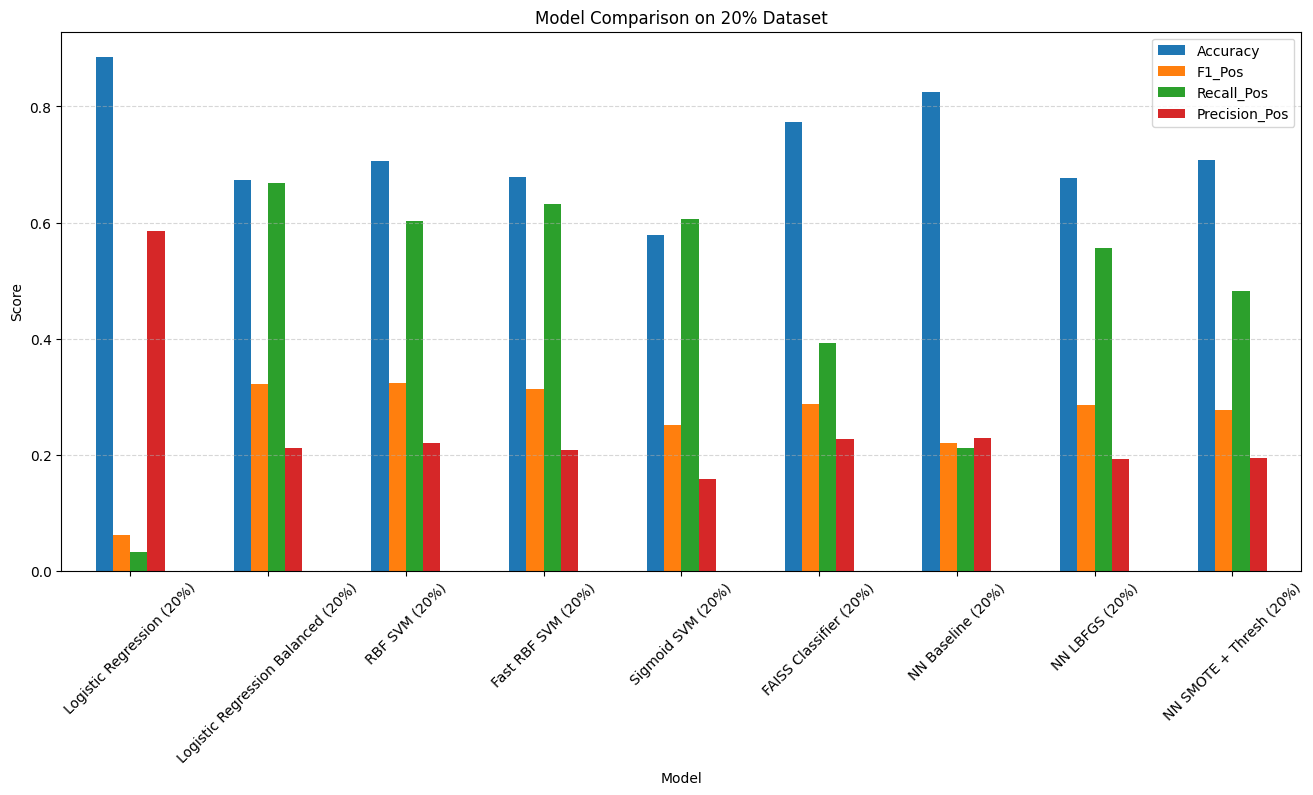

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

df_res = pd.DataFrame(results_20)

metrics = ["Accuracy", "F1_Pos", "Recall_Pos", "Precision_Pos"]

plt.figure(figsize=(14, 8))
df_res.set_index("Model")[metrics].plot(kind="bar", figsize=(16, 7))
plt.title("Model Comparison on 20% Dataset")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### Dumping the files in joblib files

In [22]:
import os
import joblib

os.makedirs("../models/models_20/", exist_ok=True)

joblib.dump(log_reg_20,       "../models/models_20/logistic.pkl")
joblib.dump(log_reg_bal_20,   "../models/models_20/logistic_balanced.pkl")
joblib.dump(rbf_svm_20,       "../models/models_20/rbf_svm.pkl")
joblib.dump(fast_rbf_svm,     "../models/models_20/fast_rbf_svm.pkl")
joblib.dump(sigmoid_svm_20,   "../models/models_20/sigmoid_svm.pkl")
joblib.dump(faiss_model,      "../models/models_20/faiss.pkl")
joblib.dump(nn_base_20,       "../models/models_20/nn_baseline.pkl")
joblib.dump(nn_lbfgs_20,      "../models/models_20/nn_lbfgs.pkl")
joblib.dump(nn_smote_20,      "../models/models_20/nn_smote.pkl")

print("All 20% models saved successfully.")


All 20% models saved successfully.
